In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl
import dabest
import warnings
warnings.simplefilter("ignore", UserWarning)


In [ ]:
base_path = "\\2. Processed\\"  
titledpath = "D:"
specifiedpath = titledpath + base_path

bin_size = 0.5  # seconds for heatmap resampling
framerate = 10  # Hz
illum_start = 60  # illumination start (seconds)
maxtime = 3600
specifictime = 200  # for shorter time plots (seconds)

#'ActivityLevel' or 'Speed'
metric_to_plot = 'Speed'

In [6]:
def filter_dead_flies(df):
    speed = df.iloc[:120].filter(regex="^Speed")
    alive = {c.split('_')[1] for c in speed.columns if speed[c].mean() >= 0.5}
    return df[[c for c in df.columns if c.split('_')[1] in alive]]

## Fig 5B (heatmap)

In [ ]:
driver = "elav"
specifictime = 121
opsin_files = {
    'elav control': specifiedpath + "w1118 x elav_ATR_5s",
    'AsOPN3 control': specifiedpath + "w1118 x OPN3_5s",
    'AsOPN3* control': specifiedpath + "w1118 x OPN3_ATR_5s"

}

# opsin_files = {
#     'ACR*': specifiedpath + "elav x ACR_5s",
#     'AsOPN3': specifiedpath + "elav x OPN3_5s",
#     'AsOPN3*': specifiedpath + "elav x OPN3_ATR_5s"

# }

opsin_title = "opsin_wt"

In [22]:
opsin_data = {}

for label, filepath in opsin_files.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]  
    opsin_data[label] = df.filter(regex="^" + metric_to_plot).T.reset_index(drop=True)

In [ ]:
num_conditions = len(opsin_data)
fig, axes = plt.subplots(num_conditions, 1, figsize=(5, 6), sharex=True)
plt.subplots_adjust(hspace=0.15)
cmaps = "YlGnBu"
if metric_to_plot == "ActivityLevel":
    scalebar_label = "Activity Level (Log10)"
elif metric_to_plot == "Speed":
    scalebar_label = "Speed (mm/s)"

vmax_number = 7

for idx, (label, data) in enumerate(opsin_data.items()):
    ax = axes[idx]
    num_flies = data.shape[0]
    
    hm = sns.heatmap(data, cmap=cmaps, cbar=False, xticklabels=False, yticklabels=False, 
                     vmin=0, vmax=vmax_number, ax=ax)
    quadmesh = ax.collections[0]
    quadmesh.set_rasterized(True)
    quadmesh.set_edgecolor('face')
    quadmesh.set_linewidth(0)
    
    ax.set_ylabel(label, rotation=0, labelpad=60, fontsize=14, weight='bold')
    ax.set_yticks([0, num_flies//2, num_flies])
    ticklabels = [num_flies, (num_flies+1)//2, 1]
    ax.set_yticklabels(ticklabels, fontsize=10)
    
    if idx < num_conditions - 1:
        ax.tick_params(axis='x', bottom=False)
        ax.set_xlabel('')
    ax.patch.set_facecolor('white')


last_data = list(opsin_data.values())[-1]
tick_times = [0, 60, specifictime - 1]
tick_positions = [list(last_data.columns).index(float(t)) for t in tick_times if float(t) in last_data.columns]
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_times, rotation=0, fontsize=12)
axes[-1].set_xlabel("Time (sec)", fontsize=14)


cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmaps, norm=plt.Normalize(vmin=0, vmax=vmax_number))
fig.colorbar(sm, cax=cbar_ax, label=scalebar_label)

fig.suptitle(opsin_title, weight="bold", fontsize=16, y=0.95)

mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')

plt.show()

## Fig 5D, E (heatmap)

In [ ]:
driver = "elav"
responder = "OPN3_ATR"

duration_files = {
    '0s':  specifiedpath + driver + " x " + responder + "_nolight",
    '5s':  specifiedpath + driver + " x " + responder + "_5s",
    '30s': specifiedpath + driver + " x " + responder + "_30s",
    '60s': specifiedpath + driver + " x " + responder + "_60s",
}
intensity_files = {
    'No Light': specifiedpath + driver + " x " + responder + "_nolight",
    'Quarter':  specifiedpath + driver + " x " + responder + "_quarter_5s",
    'Half':     specifiedpath + driver + " x " + responder + "_half_5s",
    'Full':     specifiedpath + driver + " x " + responder + "_5s",
}

duration_specifictime  = 360
intensity_specifictime = 361
duration_split_map  = {'0s': 'odd', '5s': 'odd'}
intensity_split_map = {'No Light': 'even', 'Full': 'even'}

plot_title_prefix = driver + " > " + responder

In [27]:
def build_stack_data(files_dict, metric, split_map, specifictime, shuffle=True):
    data = {}
    for label, filepath in files_dict.items():
        df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
        df = filter_dead_flies(df)
        df = df.iloc[0:(specifictime * 2), :]
        cols = sorted([c for c in df.columns if c.startswith(metric)],
                      key=lambda c: int(c.split('_')[1]))
        split = split_map.get(label)
        if split == 'even':
            cols = cols[1::2]
        elif split == 'odd':
            cols = cols[0::2]
        d = df[cols].T.reset_index(drop=True)
        data[label] = d.sample(frac=1, random_state=0).reset_index(drop=True) if shuffle else d
    return data


def _nearest_col_idx(cols, target):
    arr = np.array([float(c) for c in cols])
    return int(np.argmin(np.abs(arr - float(target))))


def draw_stack(axes, data_dict, title, tick_times, cmap='YlGnBu', vmax=7, labelpad=30):
    for idx, (label, data) in enumerate(data_dict.items()):
        ax = axes[idx]
        num_flies = data.shape[0]
        sns.heatmap(data, cmap=cmap, cbar=False, xticklabels=False, yticklabels=False,
                    vmin=0, vmax=vmax, ax=ax)
        qm = ax.collections[0]
        qm.set_rasterized(True)
        qm.set_edgecolor('face')
        qm.set_linewidth(0)
        ax.set_ylabel(label, rotation=0, labelpad=labelpad, fontsize=14, weight='bold')
        ax.set_yticks([0, num_flies // 2, num_flies])
        ax.set_yticklabels([num_flies, (num_flies + 1) // 2, 1], fontsize=10)
        if idx < len(axes) - 1:
            ax.tick_params(axis='x', bottom=False, labelbottom=False)
            ax.set_xlabel('')
        ax.patch.set_facecolor('white')
    last_data = list(data_dict.values())[-1]
    tick_positions = [_nearest_col_idx(last_data.columns, t) for t in tick_times]
    axes[-1].set_xticks(tick_positions)
    axes[-1].set_xticklabels([int(t) for t in tick_times], rotation=0, fontsize=12)
    axes[-1].set_xlabel("Time (sec)", fontsize=14)
    axes[0].set_title(title, weight="bold", fontsize=14, pad=15)


METRIC_SETTINGS = {
    'Speed':         ("Speed (mm/s)", 7),
    'ActivityLevel': ("Activity Level (Log10)", 3.5),
}


def plot_duration_vs_intensity(metric, cmap='YlGnBu', col_gap=0.45):
    scalebar_label, vmax = METRIC_SETTINGS[metric]

    dur_data = build_stack_data(duration_files, metric, duration_split_map, duration_specifictime)
    int_data = build_stack_data(intensity_files, metric, intensity_split_map, intensity_specifictime)

    n_rows = max(len(dur_data), len(int_data))

    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(n_rows, 3,
                          width_ratios=[1, 1, 0.04],
                          wspace=col_gap, hspace=0.15,
                          left=0.08, right=0.95, top=0.92, bottom=0.1)

    dur_axes = [fig.add_subplot(gs[0, 0])]
    for i in range(1, len(dur_data)):
        dur_axes.append(fig.add_subplot(gs[i, 0], sharex=dur_axes[0]))
    int_axes = [fig.add_subplot(gs[0, 1])]
    for i in range(1, len(int_data)):
        int_axes.append(fig.add_subplot(gs[i, 1], sharex=int_axes[0]))

    draw_stack(dur_axes, dur_data,
               f"{plot_title_prefix} - Illumination Duration ({metric})",
               [0, 60, 90, 120, duration_specifictime],
               cmap=cmap, vmax=vmax)
    draw_stack(int_axes, int_data,
               f"{plot_title_prefix} - Light Intensity ({metric})",
               [0, 60, intensity_specifictime],
               cmap=cmap, vmax=vmax, labelpad=40)

    cbar_ax = fig.add_subplot(gs[:, 2])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=vmax))
    fig.colorbar(sm, cax=cbar_ax, label=scalebar_label)

    mpl.rcParams['svg.fonttype'] = 'none'
    fig.patch.set_facecolor('white')
    plt.show()

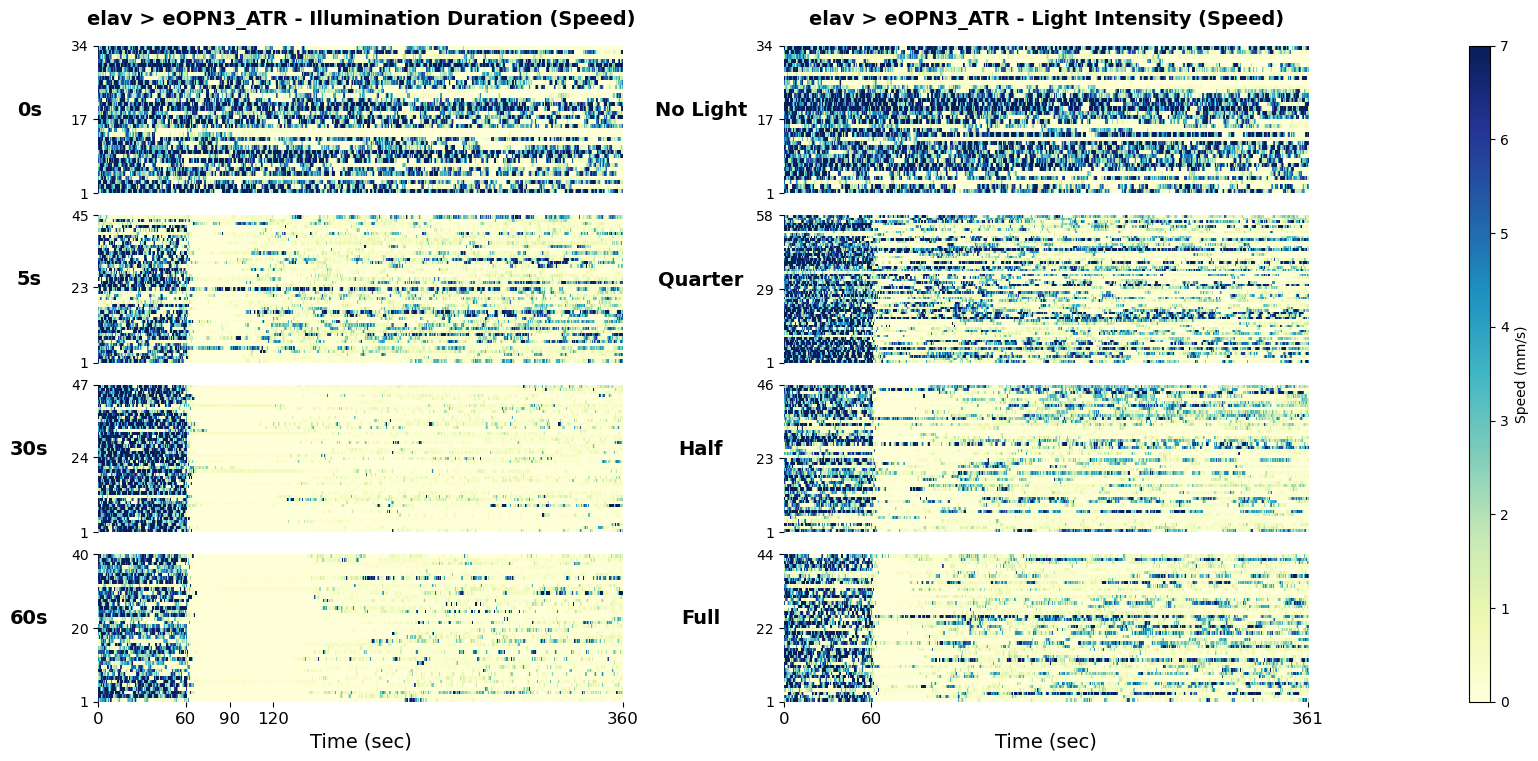

In [28]:
plot_duration_vs_intensity('Speed')

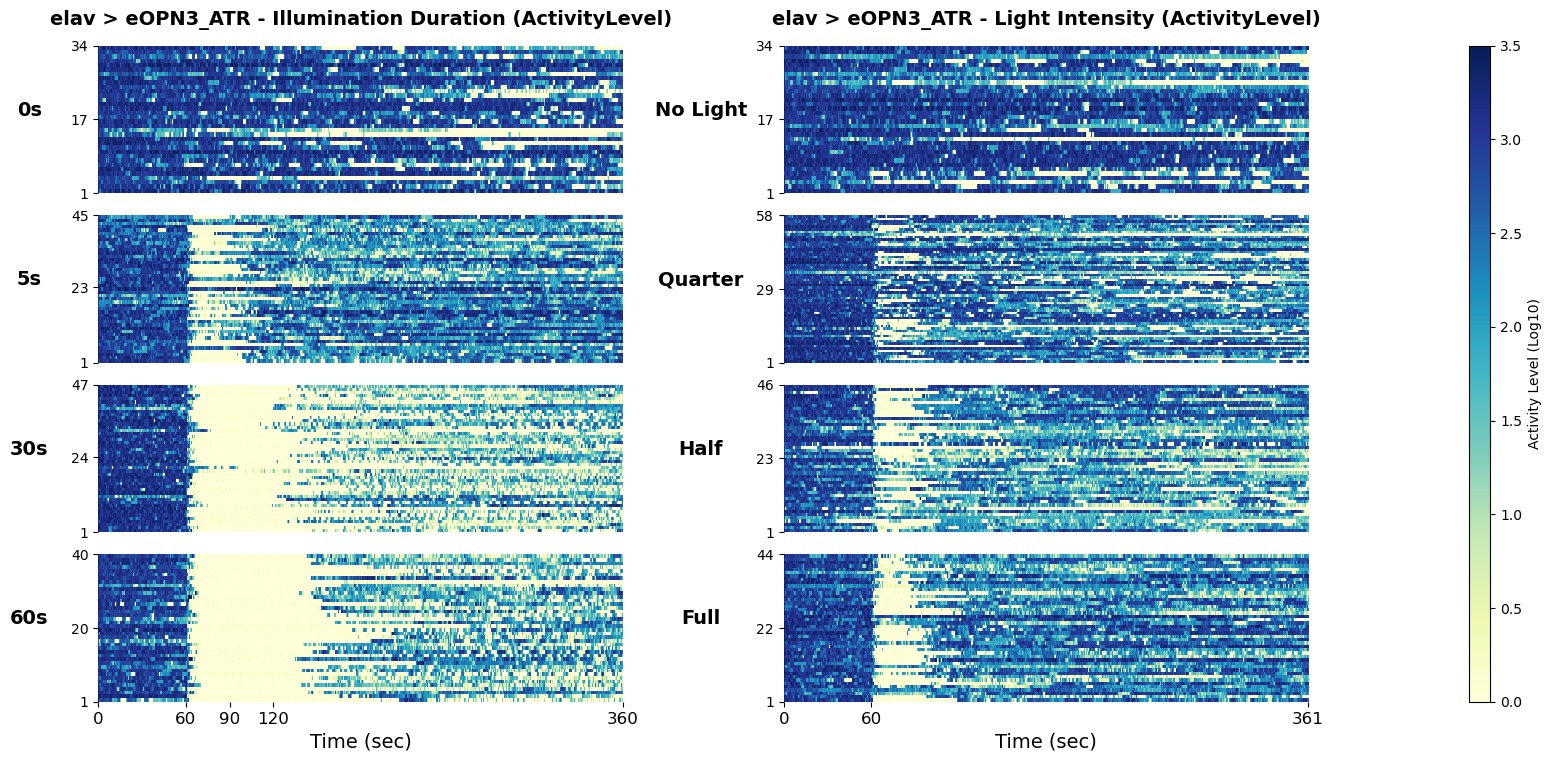

In [29]:
plot_duration_vs_intensity('ActivityLevel')

## Fig 5F, G and Supp 11C-D, 12B, D (dabest plots)

In [ ]:
def get_phases(light_duration_s=5.0):
    baseline = 60 * 2
    light_dur = light_duration_s * 2
    light_off = baseline + light_dur
    first_phase = slice(0, baseline - 0.5)
    light_on = slice(baseline, baseline + light_dur - 0.5)
    first_min = slice(light_off, light_off + 120 - 0.5)
    third_min = slice(light_off + 240, light_off + 360 - 0.5)
    fifth_min = slice(light_off + 480, light_off + 600 - 0.5)
    return first_phase, light_on, first_min, third_min, fifth_min


def load_and_split(filepath, phase_slice, split=None):
    df = pd.read_csv(filepath + "_max3600s.csv").set_index('Time (s)')
    df = filter_dead_flies(df)
    df = df.loc[phase_slice, :]
    speed_cols    = sorted([c for c in df.columns if c.startswith('Speed')],         key=lambda c: int(c.split('_')[1]))
    activity_cols = sorted([c for c in df.columns if c.startswith('ActivityLevel')], key=lambda c: int(c.split('_')[1]))
    if split == 'even':
        speed_cols    = speed_cols[1::2]
        activity_cols = activity_cols[1::2]
    elif split == 'odd':
        speed_cols    = speed_cols[0::2]
        activity_cols = activity_cols[0::2]
    return df[speed_cols].T.reset_index(drop=True), df[activity_cols].T.reset_index(drop=True)


DABEST_SPEED_PALETTE    = ["gray", "#535353", "#59B4FF", "#234BFF", "#0300B1"]
DABEST_ACTIVITY_PALETTE = ["gray", "#535353", "#FF5BBA", "#C510DD", "#830094"]
DABEST_INTENSITY_IDX = ("No Light_control", "No Light_expt", "Quarter_expt", "Half_expt", "Full_expt")
DABEST_DURATION_IDX  = ("0s_control", "0s_expt", "5s_expt", "30s_expt", "60s_expt")


def _records_to_df(records):
    s = pd.concat([r[1] for r in records], axis=1, ignore_index=True)
    a = pd.concat([r[2] for r in records], axis=1, ignore_index=True)
    s.columns = [r[0] for r in records]
    a.columns = [r[0] for r in records]
    return s, a


def build_intensity_dabest(driver, responder, w1118="w1118", both_controls=False):
    _, _, first_min, _, _ = get_phases(5.0)
    ctrl_s_no,   ctrl_a_no   = load_and_split(specifiedpath + w1118  + " x " + responder + "_0s",      first_min, 'even')
    ctrl_s_full, ctrl_a_full = load_and_split(specifiedpath + driver + " x " + responder + "_nolight", first_min, 'even')
    if both_controls:
        drv_s, drv_a = load_and_split(specifiedpath + w1118 + " x " + driver + "_ATR_0s", first_min, 'even')
        ctrl_s_no = pd.concat([ctrl_s_no, drv_s], ignore_index=True)
        ctrl_a_no = pd.concat([ctrl_a_no, drv_a], ignore_index=True)
    records = [
        ('No Light_control', ctrl_s_no.mean(axis=1),   ctrl_a_no.mean(axis=1)),
        ('Full_control',     ctrl_s_full.mean(axis=1), ctrl_a_full.mean(axis=1)),
    ]
    for label, suffix, split in [
        ('Quarter_control', "_quarter_5s", None),
        ('Half_control',    "_half_5s",    None),
        ('No Light_expt',   "_nolight",    'even'),
        ('Quarter_expt',    "_quarter_5s", None),
        ('Half_expt',       "_half_5s",    None),
        ('Full_expt',       "_5s",         'even'),
    ]:
        prefix = w1118 if label.endswith('_control') else driver
        s_df, a_df = load_and_split(specifiedpath + prefix + " x " + responder + suffix, first_min, split)
        records.append((label, s_df.mean(axis=1), a_df.mean(axis=1)))
    return _records_to_df(records)


def build_duration_dabest(driver, responder, w1118="w1118", both_controls=False):
    _, _, fm_60, _, _ = get_phases(60)
    ctrl_s_0s, ctrl_a_0s = load_and_split(specifiedpath + w1118  + " x " + responder + "_0s",      fm_60, 'odd')
    expt_s_0s, expt_a_0s = load_and_split(specifiedpath + driver + " x " + responder + "_nolight", fm_60, 'odd')
    if both_controls:
        drv_s, drv_a = load_and_split(specifiedpath + w1118 + " x " + driver + "_ATR_0s", fm_60, 'odd')
        ctrl_s_0s = pd.concat([ctrl_s_0s, drv_s], ignore_index=True)
        ctrl_a_0s = pd.concat([ctrl_a_0s, drv_a], ignore_index=True)
    records = [
        ('0s_control', ctrl_s_0s.mean(axis=1), ctrl_a_0s.mean(axis=1)),
        ('0s_expt',    expt_s_0s.mean(axis=1), expt_a_0s.mean(axis=1)),
    ]
    for label, suffix, split in [
        ('5s_control',  "_5s",  None),
        ('30s_control', "_30s", None),
        ('60s_control', "_60s", None),
        ('5s_expt',     "_5s",  'odd'),
        ('30s_expt',    "_30s", None),
        ('60s_expt',    "_60s", None),
    ]:
        duration = int(label.split('s_')[0])
        _, _, fm, _, _ = get_phases(duration)
        prefix = w1118 if label.endswith('_control') else driver
        s_df, a_df = load_and_split(specifiedpath + prefix + " x " + responder + suffix, fm, split)
        records.append((label, s_df.mean(axis=1), a_df.mean(axis=1)))
    return _records_to_df(records)


def plot_dabest_combined(driver, responder, phase="1st_min", save=False):
    int_s, int_a = build_intensity_dabest(driver, responder)
    dur_s, dur_a = build_duration_dabest(driver, responder)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), gridspec_kw={'hspace': 0.45, 'wspace': 0.35})
    common_style = {'fontsize_rawxlabel': 9, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 9,
                    'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

    panels = [
        (axes[0, 0], dabest.load(dur_s, idx=DABEST_DURATION_IDX),  DABEST_SPEED_PALETTE,    "Avg Speed (mm/s)",        "Δ Speed",    (-0.5, 8), (-10, 1), "Duration"),
        (axes[0, 1], dabest.load(dur_a, idx=DABEST_DURATION_IDX),  DABEST_ACTIVITY_PALETTE, "Avg Activity (Log10)",    "Δ Activity", (-0.5, 4), (-20, 1), "Duration"),
        (axes[1, 0], dabest.load(int_s, idx=DABEST_INTENSITY_IDX), DABEST_SPEED_PALETTE,    "Avg Speed (mm/s)",        "Δ Speed",    (-0.5, 8), (-10, 1), "Intensity"),
        (axes[1, 1], dabest.load(int_a, idx=DABEST_INTENSITY_IDX), DABEST_ACTIVITY_PALETTE, "Avg Activity (Log10)",    "Δ Activity", (-0.5, 4), (-20, 1), "Intensity"),
    ]
    for ax, db, palette, raw_lbl, contrast_lbl, raw_ylim, contrast_ylim, row_lbl in panels:
        db.hedges_g.plot(raw_label=f"{raw_lbl}\n{phase} after LIGHT OFF ({row_lbl})",
                         custom_palette=palette, raw_marker_size=3,
                         contrast_label=contrast_lbl, raw_ylim=raw_ylim, contrast_ylim=contrast_ylim,
                         ax=ax, **common_style)

    axes[0, 0].set_title("Duration",  weight='bold', fontsize=14, pad=15, loc='left')
    axes[1, 0].set_title("Intensity", weight='bold', fontsize=14, pad=15, loc='left')

    fig.suptitle(f"{driver} > {responder}", weight="bold", fontsize=14, y=0.995)
    mpl.rcParams['svg.fonttype'] = 'none'

    plt.show()

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 19.81it/s]

Numba compilation complete!


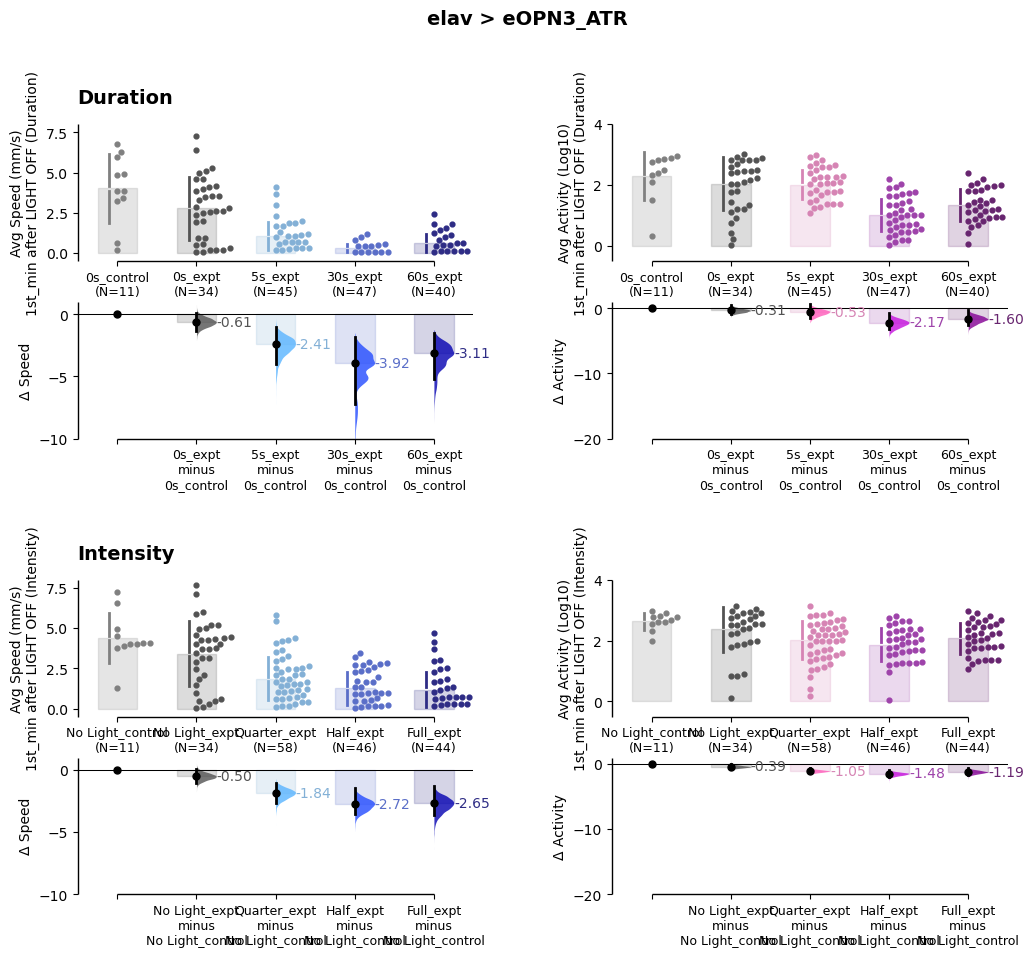

In [ ]:
plot_dabest_combined('elav', 'OPN3_ATR')

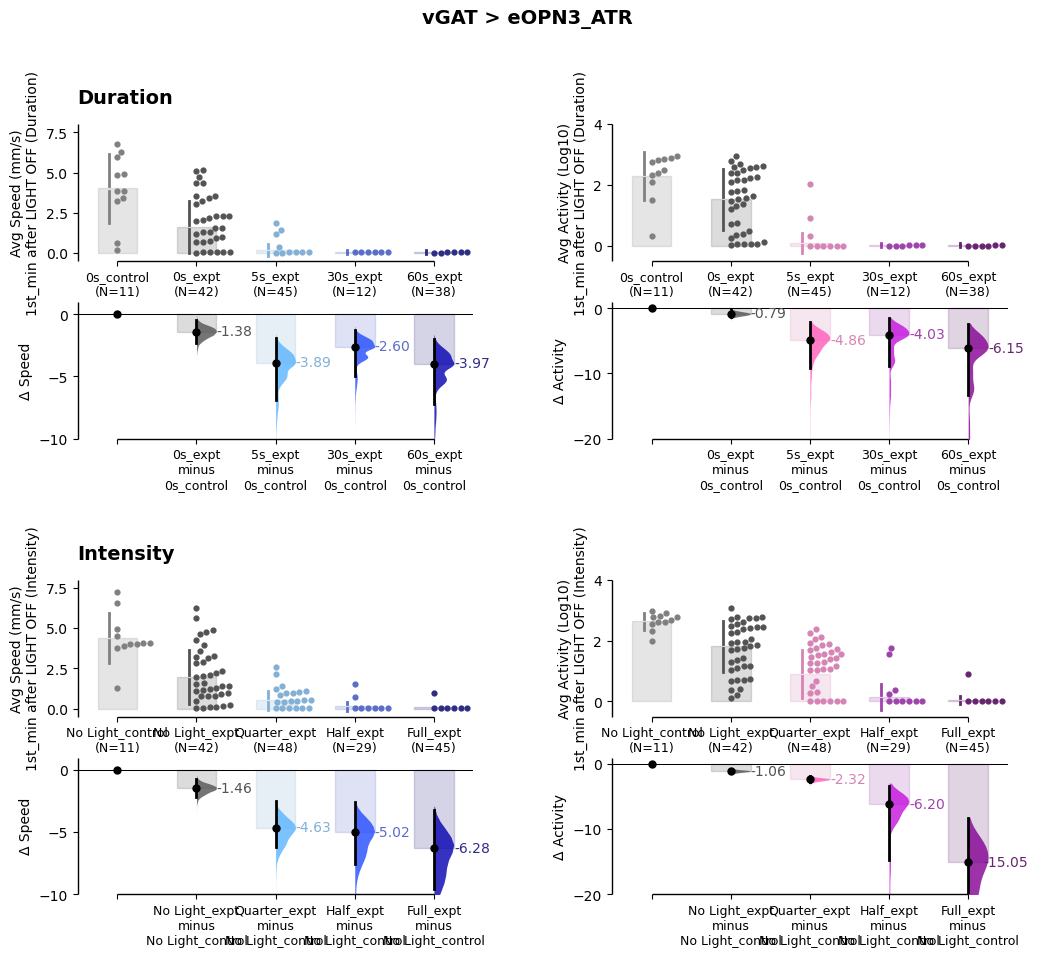

In [ ]:
plot_dabest_combined('vGAT', 'OPN3_ATR')

## Supp 12 (Line Graphs)

In [35]:
from matplotlib.patches import Rectangle


DURATION_LINE_COLORS = {
    '0s':  "#333333",
    '5s':  "#0072B2",
    '30s': "#D55E00",
    '60s': "#8F12C0",
}
INTENSITY_LINE_COLORS = {
    'No Light': "#333333",
    'Quarter':  "#0072B2",
    'Half':     "#D55E00",
    'Full':     "#8F12C0",
}


def _build_line_data(files_dict, specifictime):
    speed_d, activity_d = {}, {}
    for label, filepath in files_dict.items():
        df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
        df = filter_dead_flies(df)
        df = df.iloc[0:(specifictime * 2), :]
        speed_d[label]    = df.filter(regex="^Speed").T.reset_index(drop=True)
        activity_d[label] = df.filter(regex="^ActivityLevel").T.reset_index(drop=True)
    return speed_d, activity_d


def _draw_line(ax, data_dict, colors, ylabel, yticks, ylim, rolling_window=50):
    for label, data in data_dict.items():
        time = data.columns.values
        mean_vals = data.mean(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
        sem_vals  = data.sem(axis=0).rolling(window=rolling_window,  center=True, min_periods=1).mean()
        ci = 1.96 * sem_vals
        ax.plot(time, mean_vals, color=colors[label], label=label, linewidth=1.5)
        ax.fill_between(time, mean_vals - ci, mean_vals + ci, color=colors[label], alpha=0.1)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Time (sec)", fontsize=12)
    ax.set_yticks(yticks)
    ax.set_ylim(*ylim)
    ax.set_xlim(0, 600)
    ax.set_xticks(np.arange(0, 601, 100))


def plot_line_graphs_combined(driver, responder, specifictime=600):
    duration_files_line = {
        '0s':  specifiedpath + driver + " x " + responder + "_nolight",
        '5s':  specifiedpath + driver + " x " + responder + "_5s",
        '30s': specifiedpath + driver + " x " + responder + "_30s",
        '60s': specifiedpath + driver + " x " + responder + "_60s",
    }
    intensity_files_line = {
        'No Light': specifiedpath + driver + " x " + responder + "_nolight",
        'Quarter':  specifiedpath + driver + " x " + responder + "_quarter_5s",
        'Half':     specifiedpath + driver + " x " + responder + "_half_5s",
        'Full':     specifiedpath + driver + " x " + responder + "_5s",
    }
    dur_s, dur_a = _build_line_data(duration_files_line,  specifictime)
    int_s, int_a = _build_line_data(intensity_files_line, specifictime)

    fig, axes = plt.subplots(2, 2, figsize=(15, 8), gridspec_kw={'wspace': 0.25, 'hspace': 0.55})

    speed_yticks = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    speed_ylim   = (0.0, 7.0)
    act_yticks   = np.arange(0, 4.0, 0.5)
    act_ylim     = (0, 3.5)

    _draw_line(axes[0, 0], dur_s, DURATION_LINE_COLORS,  "Average Speed (mm/s)",     speed_yticks, speed_ylim)
    _draw_line(axes[0, 1], dur_a, DURATION_LINE_COLORS,  "Average Activity (Log10)", act_yticks,   act_ylim)
    _draw_line(axes[1, 0], int_s, INTENSITY_LINE_COLORS, "Average Speed (mm/s)",     speed_yticks, speed_ylim)
    _draw_line(axes[1, 1], int_a, INTENSITY_LINE_COLORS, "Average Activity (Log10)", act_yticks,   act_ylim)

    # Light-pulse rectangles above each row
    for ax in axes[0, :]:
        ymax = ax.get_ylim()[1]
        bar_h = ymax * 0.03
        ax.add_patch(Rectangle((60, ymax * 1.02), 60, bar_h, facecolor="#1E94018F", edgecolor='black', linewidth=0.5, clip_on=False))
        ax.add_patch(Rectangle((60, ymax * 1.06), 30, bar_h, facecolor="#1E94018F", edgecolor='black', linewidth=0.5, clip_on=False))
        ax.add_patch(Rectangle((60, ymax * 1.10),  5, bar_h, facecolor="#1E94018F", edgecolor='black', linewidth=0.5, clip_on=False))
    for ax in axes[1, :]:
        ymax = ax.get_ylim()[1]
        bar_h = ymax * 0.03
        ax.add_patch(Rectangle((60, ymax * 1.02), 5, bar_h, facecolor="#1E94018F", edgecolor='black', linewidth=0.5, clip_on=False))

    # Row labels
    axes[0, 0].set_title("Duration",  weight='bold', fontsize=14, pad=25, loc='left')
    axes[1, 0].set_title("Intensity", weight='bold', fontsize=14, pad=25, loc='left')

    # Legend per row, anchored to the right edge of each row's second subplot
    h0, l0 = axes[0, 0].get_legend_handles_labels()
    h1, l1 = axes[1, 0].get_legend_handles_labels()
    axes[0, 1].legend(h0, l0, loc='upper right', bbox_to_anchor=(1.25, 1.0), frameon=False, fontsize=9, title='Duration')
    axes[1, 1].legend(h1, l1, loc='upper right', bbox_to_anchor=(1.25, 1.0), frameon=False, fontsize=9, title='Intensity')

    fig.suptitle(f"{driver} > {responder}", weight="bold", fontsize=14, y=0.995)
    mpl.rcParams['svg.fonttype'] = 'none'
    fig.patch.set_facecolor('white')
    plt.tight_layout(rect=[0, 0, 0.96, 1])
    plt.show()

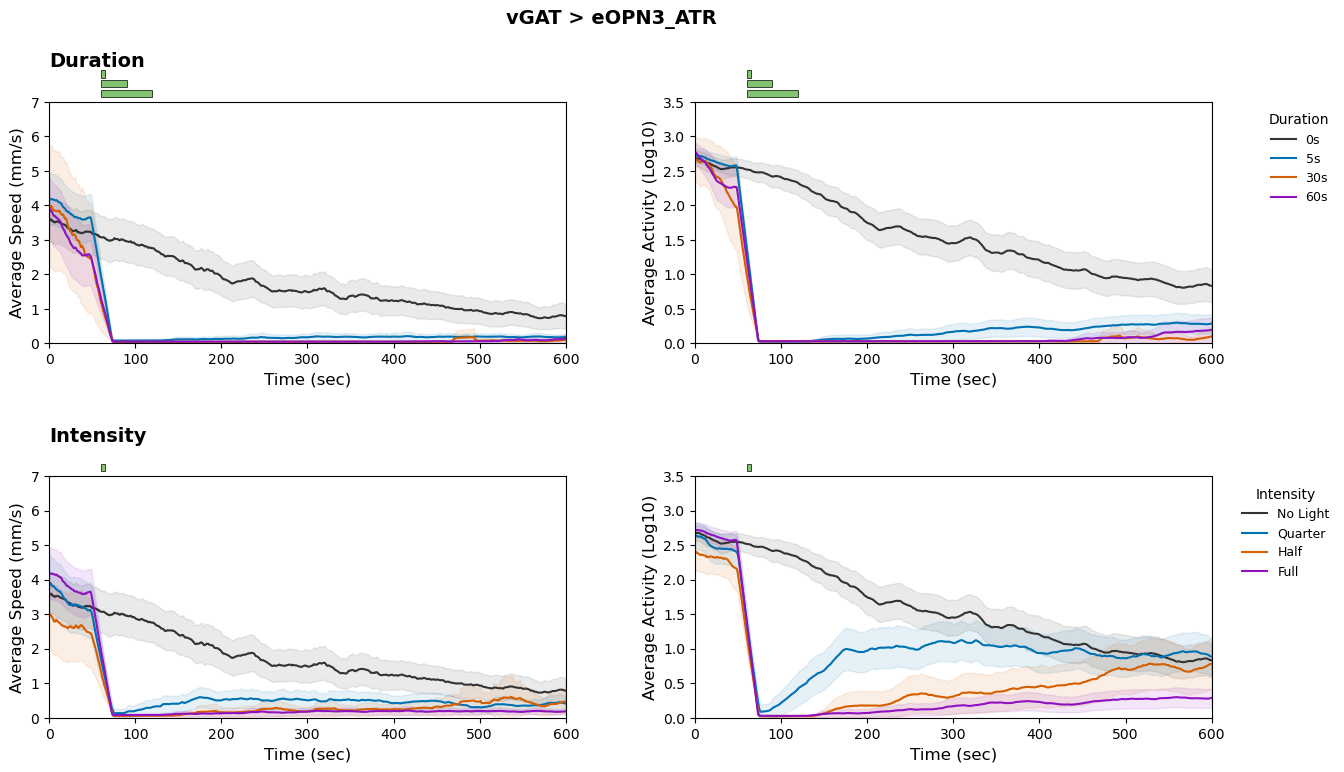

In [ ]:
plot_line_graphs_combined('vGAT', 'OPN3_ATR')